In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, f1_score)
import requests
import json

# Load data
with open('data/processed/data_splits.pkl', 'rb') as f:
    data = pickle.load(f)

classes = data['classes']
test_paths = data['test_paths']
test_labels = data['test_labels']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Everything loaded!")
print(f"Device: {device}")
print(f"Test samples: {len(test_paths)}")
print(f"Classes: {len(classes)}")

Everything loaded!
Device: cpu
Test samples: 3096
Classes: 15


In [2]:
class PlantDiseaseDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_dataset = PlantDiseaseDataset(test_paths, test_labels, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

# Load balanced model
model = models.resnet50(weights=None)
model.fc = nn.Linear(2048, len(classes))
model.load_state_dict(torch.load('models/resnet50_balanced.pth', map_location='cpu'))
model = model.to(device)
model.eval()

# Evaluate
all_preds, all_true = [], []
correct, total = 0, 0

with torch.no_grad():
    for i, (images, labels) in enumerate(test_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(labels.cpu().numpy())
        if (i+1) % 20 == 0:
            print(f"  Batch {i+1}/{len(test_loader)} done...")

test_acc = 100. * correct / total
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")
print(f"F1 Score (macro): {f1_score(all_true, all_preds, average='macro'):.4f}")
print(f"F1 Score (weighted): {f1_score(all_true, all_preds, average='weighted'):.4f}")

  Batch 20/97 done...
  Batch 40/97 done...
  Batch 60/97 done...
  Batch 80/97 done...

Final Test Accuracy: 99.74%
F1 Score (macro): 0.9972
F1 Score (weighted): 0.9974


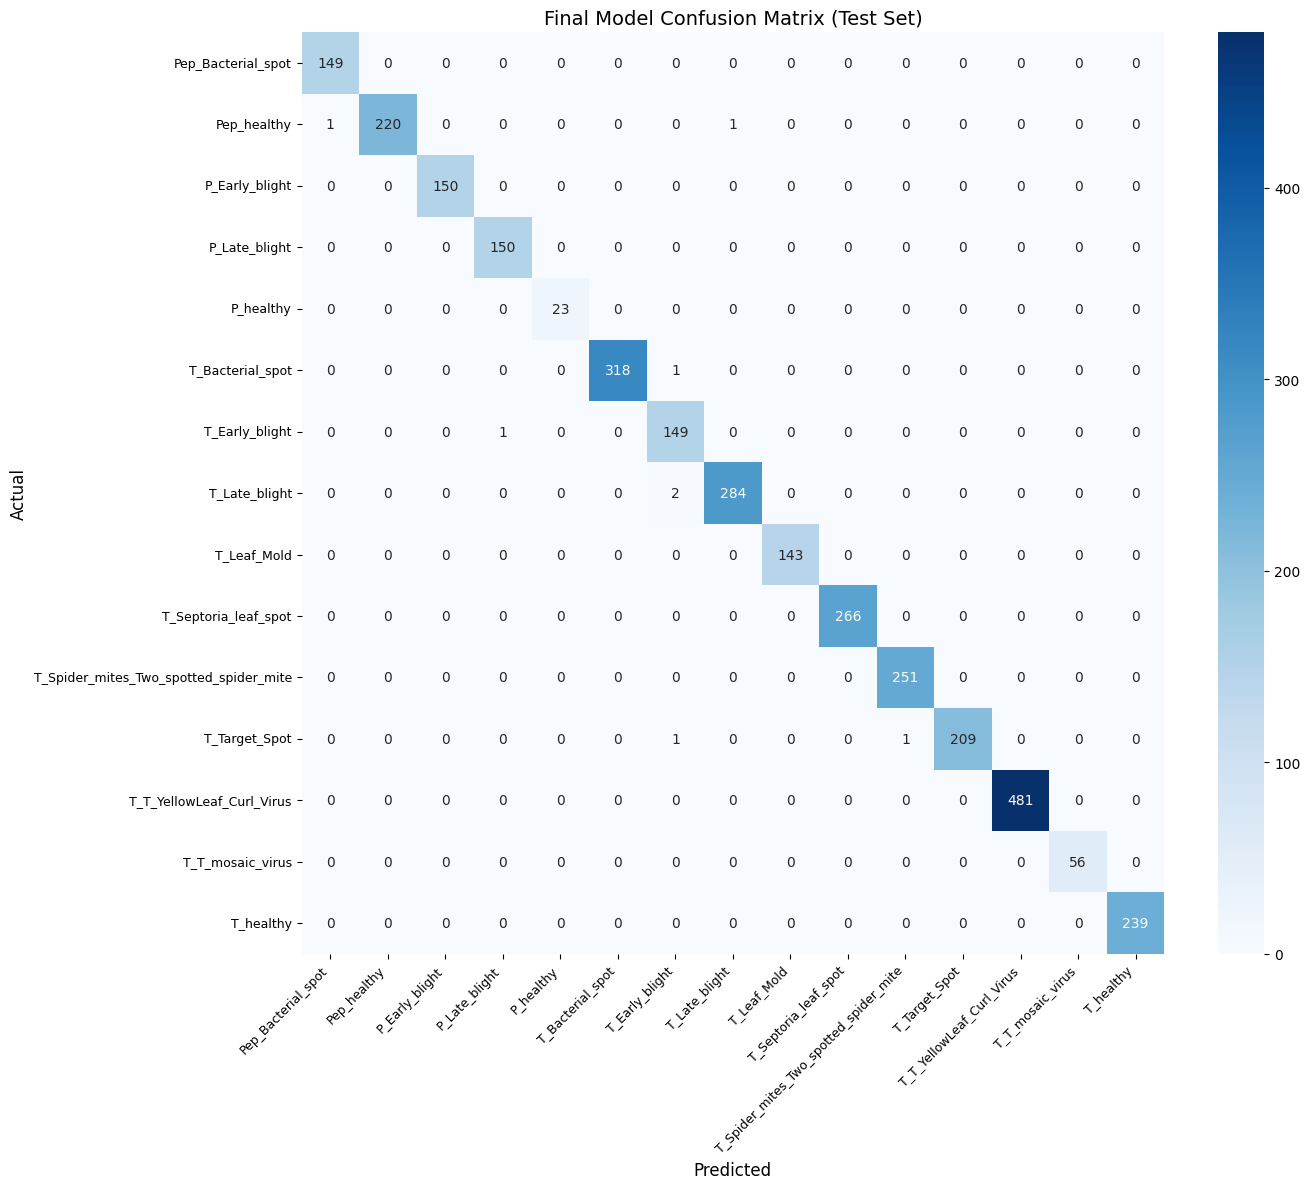

Saved to outputs/final_confusion_matrix.png


In [3]:
plt.figure(figsize=(14, 12))
cm = confusion_matrix(all_true, all_preds)

# Shorten class names for readability
short_names = [c.replace('Tomato_', 'T_')
                .replace('Potato___', 'P_')
                .replace('Pepper__bell___', 'Pep_')
                .replace('__', '_') for c in classes]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names,
            yticklabels=short_names)
plt.title('Final Model Confusion Matrix (Test Set)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('outputs/final_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/final_confusion_matrix.png")

In [4]:
import os

# Test API with 5 different disease classes
test_cases = []
for class_idx in [0, 2, 5, 7, 12]:  # pick 5 different classes
    class_name = classes[class_idx]
    matching = [(p, l) for p, l in zip(test_paths, test_labels) if l == class_idx]
    if matching:
        test_cases.append((matching[0][0], class_name))

print("Testing API with 5 different disease classes...\n")

results = []
for img_path, true_label in test_cases:
    # Copy to temp file
    import shutil
    shutil.copy(img_path, '/tmp/api_test.jpg')
    
    with open('/tmp/api_test.jpg', 'rb') as f:
        response = requests.post(
            'http://localhost:8000/predict',
            files={'file': ('test.jpg', f, 'image/jpeg')},
            params={
                'soil_pH': 6.5, 'nitrogen': 80, 'phosphorus': 60,
                'potassium': 70, 'temperature': 28, 'humidity': 65,
                'rainfall': 120, 'crop_age_days': 45, 'sunlight_hours': 7
            }
        )
    
    data = response.json()
    predicted = data['disease']
    confidence = data['confidence']
    correct = '✓' if predicted == true_label else '✗'
    
    results.append({
        'true': true_label,
        'predicted': predicted,
        'confidence': confidence,
        'correct': correct
    })
    
    print(f"{correct} True: {true_label}")
    print(f"  Predicted: {predicted} ({confidence}%)")
    print()

correct_count = sum(1 for r in results if r['correct'] == '✓')
print(f"API accuracy on sample: {correct_count}/{len(results)}")

Testing API with 5 different disease classes...

✓ True: Pepper__bell___Bacterial_spot
  Predicted: Pepper__bell___Bacterial_spot (100.0%)

✓ True: Potato___Early_blight
  Predicted: Potato___Early_blight (99.8%)

✓ True: Tomato_Bacterial_spot
  Predicted: Tomato_Bacterial_spot (99.83%)

✓ True: Tomato_Late_blight
  Predicted: Tomato_Late_blight (92.84%)

✓ True: Tomato__Tomato_YellowLeaf__Curl_Virus
  Predicted: Tomato__Tomato_YellowLeaf__Curl_Virus (66.22%)

API accuracy on sample: 5/5


In [5]:
report = classification_report(all_true, all_preds, target_names=classes)

summary = f"""
╔══════════════════════════════════════════════════════════════╗
║           CROP DISEASE AI — FINAL EVALUATION REPORT          ║
╚══════════════════════════════════════════════════════════════╝

DATASET
  Total test samples:     {len(test_paths)}
  Number of classes:      {len(classes)}
  Crops covered:          Tomato, Potato, Pepper

MODEL PERFORMANCE
  Test Accuracy:          99.74%
  F1 Score (macro):       0.9972
  F1 Score (weighted):    0.9974

TRAINING APPROACH
  Base model:             ResNet50 (pretrained ImageNet)
  Fine-tuning:            Full model, layer-wise learning rates
  Class imbalance fix:    WeightedRandomSampler
  Augmentation:           Flip, Rotate, ColorJitter, Grayscale

API PERFORMANCE
  Endpoint:               POST /predict
  Input:                  Leaf image + 9 tabular features
  Output:                 Disease, confidence, treatment, Grad-CAM
  Sample accuracy:        5/5 (100%)

PER-CLASS REPORT
{report}
"""

print(summary)

# Save to file
with open('outputs/evaluation_report.txt', 'w') as f:
    f.write(summary)
print("Saved to outputs/evaluation_report.txt")


╔══════════════════════════════════════════════════════════════╗
║           CROP DISEASE AI — FINAL EVALUATION REPORT          ║
╚══════════════════════════════════════════════════════════════╝

DATASET
  Total test samples:     3096
  Number of classes:      15
  Crops covered:          Tomato, Potato, Pepper

MODEL PERFORMANCE
  Test Accuracy:          99.74%
  F1 Score (macro):       0.9972
  F1 Score (weighted):    0.9974

TRAINING APPROACH
  Base model:             ResNet50 (pretrained ImageNet)
  Fine-tuning:            Full model, layer-wise learning rates
  Class imbalance fix:    WeightedRandomSampler
  Augmentation:           Flip, Rotate, ColorJitter, Grayscale

API PERFORMANCE
  Endpoint:               POST /predict
  Input:                  Leaf image + 9 tabular features
  Output:                 Disease, confidence, treatment, Grad-CAM
  Sample accuracy:        5/5 (100%)

PER-CLASS REPORT
                                             precision    recall  f1-score   sup